# ML — Predicción del Precio de Coches de Segunda Mano en Europa

**Objetivo:** Construir un modelo de Machine Learning capaz de predecir el precio de un coche de segunda mano en el mercado español, a partir de un dataset de anuncios reales de AutoScout24 con datos de varios países europeos.

**Dataset:** EU Used Cars — Kaggle (alemazz11/cars-europe)  
**Mercado objetivo:** España  
**Tipo de problema:** Regresión supervisada

In [1]:
import kagglehub
import pickle
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

## Paso 1: Obtención de datos

In [2]:
path = kagglehub.dataset_download("alemazz11/cars-europe")
print(path)

/home/jorge/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1


In [3]:
df = pd.read_csv(path + "/fullGas.csv")
df.head()

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,Drivetrain,Gearbox,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,Front Wheel Drive,Automatic,NaN,179,1368.0,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,Front Wheel Drive,Manual,5.0,165,1368.0,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,Front Wheel Drive,Manual,5.0,300,1368.0,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,Front Wheel Drive,Manual,5.0,160,1368.0,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,Front Wheel Drive,Manual,6.0,145,1368.0,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40494 entries, 0 to 40493
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  40494 non-null  str    
 1   Model                 40273 non-null  str    
 2   Body                  40493 non-null  str    
 3   Mileage_km            40494 non-null  int64  
 4   Price                 40494 non-null  int64  
 5   Year                  38799 non-null  float64
 6   Country               37902 non-null  str    
 7   Condition             40494 non-null  str    
 8   Fuel_Type             40465 non-null  str    
 9   Fuel_Consumption_l    12773 non-null  float64
 10  Drivetrain            31860 non-null  str    
 11  Gearbox               40014 non-null  str    
 12  Gears                 25115 non-null  float64
 13  Power_hp              40494 non-null  int64  
 14  Engine_Size_cc        34564 non-null  float64
 15  Cylinders             30332 no

### Primer contacto
40.494 registros y 25 columnas. Hay bastantes missings en varias columnas: `Fuel_Consumption_l` es la más grave con solo 12.773 valores válidos, pero también `Drivetrain`, `Gears`, `Cylinders` y `Upholstery` tienen huecos considerables. `Year` y `Country` también fallan en algunos registros. El target `Price` está completo, que es lo importante.

`Image_url` son links a fotos de los anuncios en AutoScout24, no aportan nada al análisis y parecen al menos muchos ya caducados (404)

In [5]:
df.drop(columns=["Image_url"], inplace=True)  # URLs caducadas, no sirven
df.shape


(40494, 24)

In [6]:
df.describe()

,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Previous_Owners
count,4.049400e+04,4.049400e+04,38799.000000,12773.000000,25115.000000,40494.000000,34564.000000,30332.000000,38697.000000,39517.000000,22271.000000
mean,7.723058e+04,5.662527e+04,2017.423877,6.727151,5.899024,231.339976,2275.084597,4.713339,4.633667,4.250879,1.406313
std,3.216313e+05,1.820272e+05,9.141150,3.544475,2.012859,179.923677,1540.972728,2.201816,1.652199,1.113654,1.027425
min,0.000000e+00,1.000000e+00,1922.000000,0.100000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1.700000e+04,1.368350e+04,2015.000000,4.700000,5.000000,116.000000,1353.000000,4.000000,5.000000,4.000000,1.000000
50%,5.599500e+04,2.219950e+04,2020.000000,5.600000,6.000000,158.000000,1598.000000,4.000000,5.000000,5.000000,1.000000
75%,1.059982e+05,3.600000e+04,2023.000000,7.200000,7.000000,280.000000,2494.000000,4.000000,5.000000,5.000000,2.000000
max,1.677722e+07,9.999999e+06,2026.000000,55.000000,69.000000,3399.000000,67500.000000,50.000000,255.000000,25.000000,94.000000


In [7]:
df["Country"].value_counts(dropna=False) #Vemos países y cuántos no tienen país

Country
DE     15494
IT      9769
NL      4179
BE      3789
NaN     2592
ES      1857
FR      1363
AT      1338
LU       113
Name: count, dtype: int64

## Paso 3: Hipótesis

Antes de entrar en el análisis planteamos las hipótesis que guiarán el EDA. Partimos de 6 candidatas — algunas se confirmarán, otras se descartarán o fusionarán según lo que vayan mostrando los datos.

1. **Kilometraje vs antigüedad:** ¿Cuál de los dos factores deprecia más el precio?
2. **Diferencias por país:** ¿Hay diferencias significativas de precio entre países para características similares?
3. **Retención de valor por marca:** ¿Hay marcas que deprecian significativamente menos que otras?
4. **Tipo de combustible:** ¿El combustible afecta al precio de forma significativa?
5. **Propietarios anteriores:** ¿Un mayor número de propietarios deprecia el precio de forma notable?
6. **Potencia:** ¿Es la potencia el factor técnico con mayor correlación con el precio?

In [8]:
df.dtypes # Tipos

Make                        str
Model                       str
Body                        str
Mileage_km                int64
Price                     int64
Year                    float64
Country                     str
Condition                   str
Fuel_Type                   str
Fuel_Consumption_l      float64
Drivetrain                  str
Gearbox                     str
Gears                   float64
Power_hp                  int64
Engine_Size_cc          float64
Cylinders               float64
Seats                   float64
Doors                   float64
Color                       str
Upholstery                  str
Full_Service_History       bool
Non_Smoker_Vehicle         bool
Previous_Owners         float64
Seller                      str
dtype: object

In [9]:
df.isnull().sum() # Missings

Make                        0
Model                     221
Body                        1
Mileage_km                  0
Price                       0
Year                     1695
Country                  2592
Condition                   0
Fuel_Type                  29
Fuel_Consumption_l      27721
Drivetrain               8634
Gearbox                   480
Gears                   15379
Power_hp                    0
Engine_Size_cc           5930
Cylinders               10162
Seats                    1797
Doors                     977
Color                    2575
Upholstery               7272
Full_Service_History        0
Non_Smoker_Vehicle          0
Previous_Owners         18223
Seller                    150
dtype: int64

## Paso 4: Tabla de variables

Con los tipos y missings analizados, inventariamos todas las columnas y su utilidad esperada.

| Variable | Tipo | Missings | % | Uso previsto |
|----------|------|----------|---|--------------|
| Make | Categórica | 0 | 0% | Usar |
| Model | Categórica | 221 | 0.5% | Usar |
| Body | Categórica | 1 | 0% | Usar |
| Mileage_km | Numérica | 0 | 0% | Usar |
| Price | Numérica | 0 | 0% | Target |
| Year | Numérica | 1.695 | 4.2% | Usar, tratable |
| Country | Categórica | 2.592 | 6.4% | Usar, clave para el análisis |
| Condition | Categórica | 0 | 0% | Usar |
| Fuel_Type | Categórica | 29 | 0.1% | Usar |
| Fuel_Consumption_l | Numérica | 27.721 | 68.5% | Descartar |
| Drivetrain | Categórica | 8.634 | 21.3% | A valorar |
| Gearbox | Categórica | 480 | 1.2% | Usar |
| Gears | Numérica | 15.379 | 38% | Descartar |
| Power_hp | Numérica | 0 | 0% | Usar |
| Engine_Size_cc | Numérica | 5.930 | 14.6% | A valorar |
| Cylinders | Numérica | 10.162 | 25.1% | A valorar |
| Seats | Numérica | 1.797 | 4.4% | Usar, tratable |
| Doors | Numérica | 977 | 2.4% | Usar, tratable |
| Color | Categórica | 2.575 | 6.4% | A valorar, baja relevancia esperada |
| Upholstery | Categórica | 7.272 | 18% | A valorar |
| Full_Service_History | Booleana | 0 | 0% | Usar |
| Non_Smoker_Vehicle | Booleana | 0 | 0% | Usar |
| Previous_Owners | Numérica | 18.223 | 45% | A valorar, relevante pero muy incompleta |
| Seller | Categórica | 150 | 0.4% | Usar |

`Fuel_Consumption_l` y `Gears` se descartan por missings excesivos. El resto marcado como "a valorar" se decidirá durante la limpieza según lo que aporten al análisis.

## Paso 5: Limpieza de datos

Empezamos descartando las columnas con missings excesivos ya identificados.

In [10]:
df.drop(columns=["Fuel_Consumption_l", "Gears"], inplace=True) # Eliminamos columnas
df.shape

(40494, 22)

### Outliers imposibles

El describe inicial reveló valores claramente erróneos en varias columnas. Los investigamos y filtramos.

In [11]:
df["Mileage_km"].describe() #Vemos kms

count    4.049400e+04
mean     7.723058e+04
std      3.216313e+05
min      0.000000e+00
25%      1.700000e+04
50%      5.599500e+04
75%      1.059982e+05
max      1.677722e+07
Name: Mileage_km, dtype: float64

In [12]:
print(f"Mileage > 300.000: {(df['Mileage_km'] > 300_000).sum()}") # Contamos por rangos
print(f"Mileage > 400.000: {(df['Mileage_km'] > 400_000).sum()}")
print(f"Mileage > 500.000: {(df['Mileage_km'] > 500_000).sum()}")
print(f"Mileage == 0: {(df['Mileage_km'] == 0).sum()}")

Mileage > 300.000: 281
Mileage > 400.000: 50
Mileage > 500.000: 25
Mileage == 0: 896


In [13]:
df[df['Mileage_km'] > 400_000][['Make', 'Model', 'Year', 'Mileage_km', 'Price', 'Country']].sort_values('Mileage_km', ascending=False).head(20)
# Muchos km? Fallos claros de NL

,Make,Model,Year,Mileage_km,Price,Country
414,Abarth,595 Turismo,2013.0,16777215,8500,NL
3854,Bentley,Brooklands,1993.0,16777215,5500,NL
7073,Chevrolet,Camaro,1985.0,16777215,6500,NL
3881,Bentley,Continental GT,2004.0,16777215,19500,NL
3956,Bentley,Continental GTC,2008.0,16777215,29500,NL
4089,Bentley,S2,1960.0,16777215,22500,NL
7158,Chevrolet,Camaro,1997.0,16777215,4500,NL
22345,Lexus,NaN,2023.0,16777215,29500,NL
20640,Lancia,Delta,1988.0,16777215,22500,NL
19612,Lamborghini,NaN,1967.0,16777215,17500,NL


In [14]:
df["Price"].describe() #vemos precios y luego los rangos

count    4.049400e+04
mean     5.662527e+04
std      1.820272e+05
min      1.000000e+00
25%      1.368350e+04
50%      2.219950e+04
75%      3.600000e+04
max      9.999999e+06
Name: Price, dtype: float64

In [15]:
print(f"Price < 500: {(df['Price'] < 500).sum()}")
print(f"Price > 200.000: {(df['Price'] > 200_000).sum()}")
print(f"Price > 300.000: {(df['Price'] > 300_000).sum()}")
print(f"Price > 500.000: {(df['Price'] > 500_000).sum()}")

Price < 500: 27
Price > 200.000: 2569
Price > 300.000: 1445
Price > 500.000: 470


In [16]:
df[df['Price'] > 200_000][['Make', 'Model', 'Year', 'Mileage_km', 'Price', 'Country']].sort_values('Price', ascending=False).head(20)
#muchos coches caros, vamos a verlos
# Citroen C3 de oro, brillantes y rubíes

,Make,Model,Year,Mileage_km,Price,Country
8280,Citroen,C3,2009.0,85516,9999999,BE
12156,Ferrari,Enzo Ferrari,2004.0,14900,7500000,DE
12203,Ferrari,F50,1996.0,32000,6500000,FR
12464,Ferrari,288,1985.0,1,6500000,ES
12064,Ferrari,Enzo Ferrari,2003.0,13222,6400000,FR
12060,Ferrari,Daytona,NaN,0,5850000,FR
12222,Ferrari,LaFerrari,2018.0,900,5700000,ES
12063,Ferrari,F50,1996.0,20666,5600000,FR
12180,Ferrari,NaN,NaN,50,5600000,FR
12334,Ferrari,Enzo Ferrari,2004.0,3988,5400000,FR


In [17]:
df[df['Price'] < 500][['Make', 'Model', 'Year', 'Mileage_km', 'Price', 'Country']]
#Veamos los muy baratos

,Make,Model,Year,Mileage_km,Price,Country
6702,Chevrolet,Kalos,2008.0,66638,499,DE
6714,Chevrolet,Lacetti,2005.0,156350,450,DE
6818,Chevrolet,Aveo,2009.0,327951,469,DE
6835,Chevrolet,Lacetti,2009.0,106900,350,DE
6884,Chevrolet,Aveo,2010.0,131112,399,DE
6893,Chevrolet,Matiz,2005.0,84000,300,DE
6906,Chevrolet,Matiz,2009.0,91000,250,DE
6920,Chevrolet,Matiz,2009.0,74000,400,DE
6962,Chevrolet,Matiz,2007.0,73821,400,NaN
6966,Chevrolet,Kalos,2006.0,173282,300,NaN


In [18]:
print(f"Price == 1: {(df['Price'] == 1).sum()}") #Menos de 100? yo quiero
print(f"Price < 100: {(df['Price'] < 100).sum()}")

Price == 1: 2
Price < 100: 3


In [19]:
df = df[(df['Price'] >= 100) & (df['Price'] < 9_999_999)] #quitamos exremos

In [20]:
print(f"Power_hp == 0: {(df['Power_hp'] == 0).sum()}")   #Vamos a revisar los cv
df[df['Power_hp'] == 0][['Make', 'Model', 'Year', 'Power_hp', 'Price', 'Country']].head(10)  

Power_hp == 0: 419


,Make,Model,Year,Power_hp,Price,Country
138,Abarth,595,2021.0,0,17490,IT
149,Abarth,595,2021.0,0,17490,IT
155,Abarth,595,2021.0,0,17490,IT
170,Abarth,500C,2010.0,0,6990,FR
172,Abarth,595,2019.0,0,12890,FR
414,Abarth,595 Turismo,2013.0,0,8500,NL
737,Abarth,595,2018.0,0,13990,FR
1160,Alfa Romeo,Tonale,2025.0,0,44900,IT
1321,Alfa Romeo,Spider,1998.0,0,6990,ES
1510,Alfa Romeo,Tonale,2025.0,0,44400,IT


In [21]:
df = df[df['Power_hp'] > 0]  #Me gustaría que hubiera menos, porque hay que eliminar, son errores

In [22]:
df = df[df['Mileage_km'] <= 500_000] #Los kms

In [23]:
df.shape  #Razonable, hemos eliminado pocos

(40060, 22)

In [24]:
print(f"Year < 1980: {(df['Year'] < 1980).sum()}")  # Vemos años
print(f"Year > 2026: {(df['Year'] > 2026).sum()}")
df['Year'].value_counts().sort_index().head(20)

Year < 1980: 485
Year > 2026: 0


Year
1926.0     1
1929.0     2
1934.0     4
1935.0     1
1936.0     3
1937.0     2
1949.0     3
1950.0     1
1952.0     2
1953.0     2
1954.0     7
1955.0     6
1956.0     6
1957.0    13
1958.0     6
1959.0    14
1960.0    13
1961.0    12
1962.0    12
1963.0    15
Name: count, dtype: int64

In [25]:
df[df['Year'] < 1970][['Make', 'Model', 'Year', 'Mileage_km', 'Price', 'Country']].sort_values('Year').head(30)
# Más de cerca los coches antiguos por si son errores

,Make,Model,Year,Mileage_km,Price,Country
33363,Rolls-Royce,NaN,1926.0,32049,109000,AT
33174,Rolls-Royce,Phantom,1929.0,196976,99900,NL
33312,Rolls-Royce,Phantom,1929.0,71997,63900,NL
33077,Rolls-Royce,NaN,1934.0,69000,43900,DE
33222,Rolls-Royce,NaN,1934.0,48000,95000,NaN
33386,Rolls-Royce,NaN,1934.0,1000,95000,NaN
33366,Rolls-Royce,NaN,1934.0,385,48000,IT
32841,Rolls-Royce,Park Ward,1935.0,80000,31500,NaN
32821,Rolls-Royce,NaN,1936.0,8320,92500,DE
33331,Rolls-Royce,NaN,1936.0,155300,109900,FR


In [26]:
print(f"Engine_Size_cc > 10.000: {(df['Engine_Size_cc'] > 10_000).sum()}")
df[df['Engine_Size_cc'] > 10_000][['Make', 'Model', 'Year', 'Engine_Size_cc', 'Price', 'Country']].head(10)
#Cilindradas por encima de 8.000 ya es bien raro

Engine_Size_cc > 10.000: 3


,Make,Model,Year,Engine_Size_cc,Price,Country
631,Abarth,695,2010.0,14368.0,26990,DE
11303,Dodge,Charger,2010.0,56654.0,16699,DE
32766,Rolls-Royce,Silver Spirit,1978.0,67500.0,19900,DE


In [27]:
#df = df[df['Engine_Size_cc'] <= 10_000]
#df.shape
#Limpiamos
#Me he cargao los nulos....
df = df[(df['Engine_Size_cc'] <= 10_000) | (df['Engine_Size_cc'].isna())]
df.shape

(40057, 22)

In [28]:
# Ahora sí, 40057 razonable

In [29]:
df = df[(df['Cylinders'] <= 12) | (df['Cylinders'].isna())]
df.shape
#Más de 12 cilindros ni un F1

(40056, 22)

In [30]:
# Asientos
df[df['Seats'] > 9][['Make', 'Model', 'Year', 'Seats', 'Price', 'Country']].head(20)

,Make,Model,Year,Seats,Price,Country
11093,Dodge,Challenger,2019.0,44.0,36990,DE
27881,Mitsubishi,Outlander,2014.0,255.0,10990,FR


In [31]:
df = df[(df['Seats'] <= 9) | (df['Seats'].isna())] #Limpiamos más de 9
df.shape

(40054, 22)

In [32]:
df['Doors'].value_counts().sort_index() #Vemos puertas

Doors
1.0        11
2.0      5850
3.0      2561
4.0      6483
5.0     24209
6.0        39
25.0        1
Name: count, dtype: int64

In [33]:
df = df[(df['Doors'] <= 6) | (df['Doors'].isna())] #Limpieza más de 6
df.shape

(40053, 22)

### Resumen de limpieza

- Columnas eliminadas: `Image_url` (URLs caducadas), `Fuel_Consumption_l` (68.5% missings), `Gears` (38% missings)
- Precios imposibles eliminados: valores por debajo de 100€ y el valor 9.999.999€ (código de error)
- Potencia 0 cv: 419 registros eliminados
- Kilometraje superior a 500.000 km eliminado
- Engine_Size_cc superior a 10.000 cc: 3 registros eliminados
- Cylinders superior a 12: 1 registro eliminado
- Seats superior a 9: 2 registros eliminado
- Doors superior a 6: 1 registro eliminado

Dataset resultante: 40.053 registros y 22 columnas. Muy razonable.

In [34]:
#Missings
df.isnull().sum().sort_values(ascending=False)

Previous_Owners         17890
Cylinders                9837
Drivetrain               8347
Upholstery               7042
Engine_Size_cc           5612
Country                  2582
Color                    2531
Year                     1682
Seats                    1562
Doors                     900
Gearbox                   455
Model                     211
Seller                    145
Fuel_Type                  24
Body                        1
Price                       0
Make                        0
Mileage_km                  0
Power_hp                    0
Condition                   0
Non_Smoker_Vehicle          0
Full_Service_History        0
dtype: int64

In [35]:
print(df['Drivetrain'].value_counts())
print(df['Upholstery'].value_counts())

Drivetrain
Front Wheel Drive    17338
4WD                   8903
Rear Wheel Drive      5465
Name: count, dtype: int64
Upholstery
Cloth           12880
Full leather    12223
Part leather     3918
Other            2076
alcantara        1703
Velour            211
Name: count, dtype: int64


In [36]:
df['Drivetrain'] = df['Drivetrain'].fillna('Front Wheel Drive')
df['Upholstery'] = df['Upholstery'].fillna('Cloth')
df['Engine_Size_cc'] = df['Engine_Size_cc'].fillna(df['Engine_Size_cc'].median())

### Tratamiento de missings

**Columnas eliminadas por missings excesivos o baja utilidad:**
- `Previous_Owners` — 44% de missings y dato fácilmente manipulable por los vendedores. Descartamos también la hipótesis 5.
- `Cylinders` — 24% de missings y redundante teniendo `Power_hp`. La potencia es lo que mira el comprador, no el número de cilindros.

**Columnas imputadas:**
- `Drivetrain` — imputado con "Front Wheel Drive". En los anuncios se destaca siempre si el coche tiene tracción trasera o 4x4, por lo que el missing casi seguro indica tracción delantera, la más común del mercado europeo.
- `Upholstery` — imputado con "Cloth". Mismo razonamiento: el cuero se anuncia, el silencio indica tapicería básica.
- `Engine_Size_cc` — imputado con la mediana. Menos relevante que la potencia pero no hay que perder filas innecesariamente.

In [37]:
df.isnull().sum().sort_values(ascending=False)

Previous_Owners         17890
Cylinders                9837
Country                  2582
Color                    2531
Year                     1682
Seats                    1562
Doors                     900
Gearbox                   455
Model                     211
Seller                    145
Fuel_Type                  24
Body                        1
Make                        0
Mileage_km                  0
Price                       0
Power_hp                    0
Condition                   0
Drivetrain                  0
Engine_Size_cc              0
Upholstery                  0
Non_Smoker_Vehicle          0
Full_Service_History        0
dtype: int64

In [38]:
df.drop(columns=['Previous_Owners', 'Cylinders'], inplace=True)
df.isnull().sum().sort_values(ascending=False)

Country                 2582
Color                   2531
Year                    1682
Seats                   1562
Doors                    900
Gearbox                  455
Model                    211
Seller                   145
Fuel_Type                 24
Body                       1
Mileage_km                 0
Make                       0
Power_hp                   0
Drivetrain                 0
Price                      0
Condition                  0
Engine_Size_cc             0
Upholstery                 0
Full_Service_History       0
Non_Smoker_Vehicle         0
dtype: int64

In [39]:
# Vamos a ver los años a ver si son coches raros o hay de todo
df[df['Year'].isna()][['Make', 'Model', 'Mileage_km', 'Price', 'Country']].head(20)

,Make,Model,Mileage_km,Price,Country
70,Abarth,600e,1,23400,IT
86,Abarth,600e,10,29750,IT
109,Abarth,600e,0,26900,IT
147,Abarth,600e,0,30000,IT
153,Abarth,600e,10,29950,IT
161,Abarth,600e,0,42950,IT
197,Abarth,500e,50,42490,DE
582,Abarth,600e,0,47490,DE
931,Alfa Romeo,Junior,0,24400,IT
1072,Alfa Romeo,Junior,0,25900,IT


In [40]:
# No me sirve, vamos a ver aleatorios
df[df['Year'].isna()][['Make', 'Model', 'Mileage_km', 'Price', 'Country']].sample(50, random_state=42)

,Make,Model,Mileage_km,Price,Country
31052,Porsche,911,0,240284,DE
11124,Dodge,RAM,10,66999,DE
36615,Suzuki,S-Cross,0,24190,IT
2305,Aston Martin,DB12,30,189007,DE
5697,BYD,Dolphin,0,20990,DE
8789,Corvette,C8,0,133000,IT
15337,Hyundai,i20,0,18799,DE
10149,Dacia,Spring,10,14955,DE
38083,Toyota,Aygo X,1,21233,DE
28544,Nissan,X-Trail,0,38685,DE


In [41]:
# Todo tipo de marcas, no tienen kms y sin fecha. Son km0 sin matricular
df['Year'] = df['Year'].fillna(df['Year'].median()) #Mediana para no perderlos

In [42]:
df['Gearbox'].value_counts() 

Gearbox
Automatic         25053
Manual            13816
Semi-automatic      729
Name: count, dtype: int64

In [43]:
# Buscamos moda y sorpresa en Las Gaunas, muchos automáticos, no puedo imputar con la moda y sól "sólo" 455 así que eliminamos
df = df.dropna(subset=['Gearbox'])
df.shape

(39598, 20)

In [44]:
# Eliminamos Filas de los que tienen pocos missings
df = df.dropna(subset=['Model', 'Seller', 'Fuel_Type', 'Body'])
df.shape

(39247, 20)

In [45]:
 # Asientos y número de puertas sí podemos ponerle la moda a los missings
df['Seats'] = df['Seats'].fillna(df['Seats'].mode()[0])
df['Doors'] = df['Doors'].fillna(df['Doors'].mode()[0])

In [46]:
# Repaso
df.isnull().sum().sort_values(ascending=False)

Color                   2350
Country                 2173
Make                       0
Model                      0
Mileage_km                 0
Body                       0
Year                       0
Price                      0
Fuel_Type                  0
Drivetrain                 0
Gearbox                    0
Condition                  0
Power_hp                   0
Engine_Size_cc             0
Seats                      0
Doors                      0
Upholstery                 0
Full_Service_History       0
Non_Smoker_Vehicle         0
Seller                     0
dtype: int64

In [47]:
# Color interesante para estudiar otro día, no lo metemos en hipótesis
df.drop(columns=['Color'], inplace=True)
df.shape

(39247, 19)

In [48]:
# Veamos duplicados por siaca
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 797


In [49]:
# Más de lo que pensé, eliminamos
df = df.drop_duplicates()
df.shape

(38450, 19)

### Decisiones sobre missings restantes

- `Color` — eliminada la columna. Aunque una estadística de colores sería curiosa, no aporta valor predictivo al modelo y tiene 2.350 missings. Preferimos no introducir ruido.
- `Year` — imputado con la mediana. La muestra de registros sin año incluía coches nuevos sin matricular (0 km, stock de concesionario) sin un patrón sospechoso, por lo que la mediana es una imputación razonable.
- `Seats` y `Doors` — imputados con la moda. Valores muy estables en el mercado general.
- `Gearbox` — eliminadas las 455 filas. Sorprendentemente la moda es "Automatic", contra la intuición del mercado europeo tradicional. Preferimos no imputar un dato tan relevante y eliminar las filas, que son pocas.
- `Model`, `Seller`, `Fuel_Type`, `Body` — eliminadas las filas directamente por ser pocos registros.
- `Country` — mantenemos los missings de momento. Se eliminarán al filtrar por España para el modelo.
- `Duplicados` — 797 registros eliminados.

Dataset final limpio: **38.450 registros y 19 columnas**. Partíamos de 40.494 filas y 25 columnas — una pérdida del 5% de registros, lo que habla de una buena calidad general del dataset.

## Paso 6: Análisis Exploratorio de Datos (EDA)

Con el dataset limpio empezamos el análisis. Primero el análisis univariante — cada variable por separado — y luego el bivariante para explorar relaciones entre ellas y con el target `Price`.

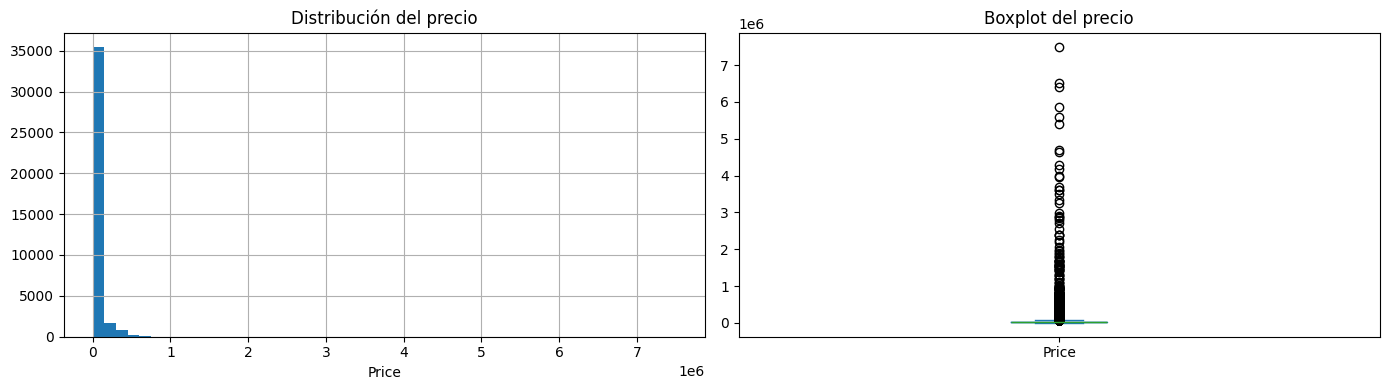

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

df['Price'].hist(bins=50, ax=ax[0])
ax[0].set_title('Distribución del precio')
ax[0].set_xlabel('Price')

df['Price'].plot(kind='box', ax=ax[1])
ax[1].set_title('Boxplot del precio')

plt.tight_layout()
plt.show()

In [51]:
#Vamos a probar valores más humanos de a pie
print(f"Coches entre 3.000 y 40.000€: {((df['Price'] >= 3_000) & (df['Price'] <= 40_000)).sum()}")
print(f"Porcentaje: {((df['Price'] >= 3_000) & (df['Price'] <= 40_000)).sum() / len(df) * 100:.1f}%")

Coches entre 3.000 y 40.000€: 29318
Porcentaje: 76.2%


In [52]:
df['Price'].describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])


count    3.845000e+04
mean     5.357849e+04
std      1.522402e+05
min      1.230000e+02
5%       4.400000e+03
10%      7.401800e+03
25%      1.349000e+04
50%      2.195000e+04
75%      3.589000e+04
90%      1.149000e+05
95%      2.390000e+05
max      7.500000e+06
Name: Price, dtype: float64

In [53]:
# Pos vale, pos me alegro, me no entender. Vamos a ver mejor
df['Price'].describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).apply(lambda x: f"{x:,.0f} €")

count       38,450 €
mean        53,578 €
std        152,240 €
min            123 €
5%           4,400 €
10%          7,402 €
25%         13,490 €
50%         21,950 €
75%         35,890 €
90%        114,900 €
95%        239,000 €
max      7,500,000 €
Name: Price, dtype: str

In [54]:
# Elegimos desde 1.000€ que aquí en España se venden, hasta cubrir el percentil 90%
df = df[(df['Price'] >= 1_000) & (df['Price'] <= 114_900)]
df.shape

(34476, 19)

### Análisis univariante — Variable objetivo: Price

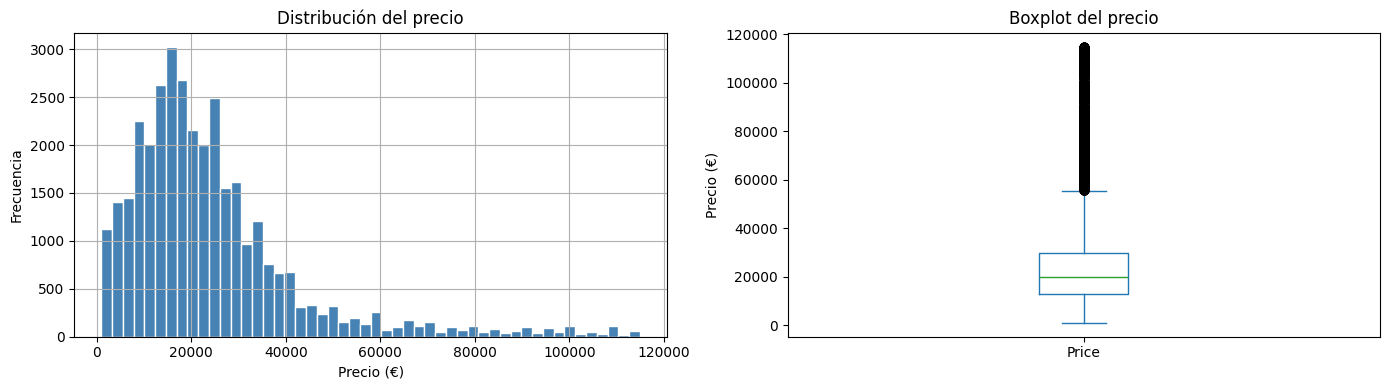

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

df['Price'].hist(bins=50, ax=ax[0], color='steelblue', edgecolor='white')
ax[0].set_title('Distribución del precio')
ax[0].set_xlabel('Precio (€)')
ax[0].set_ylabel('Frecuencia')

df['Price'].plot(kind='box', ax=ax[1])
ax[1].set_title('Boxplot del precio')
ax[1].set_ylabel('Precio (€)')

plt.tight_layout()
plt.show()

La distribución del precio muestra un sesgo positivo claro — la mayoría de coches se concentra entre 5.000 y 35.000€ con el pico alrededor de 15.000-20.000€. El boxplot confirma la mediana en torno a 20.000€ con una cola larga hacia la derecha correspondiente a coches de gama alta dentro del rango acotado.

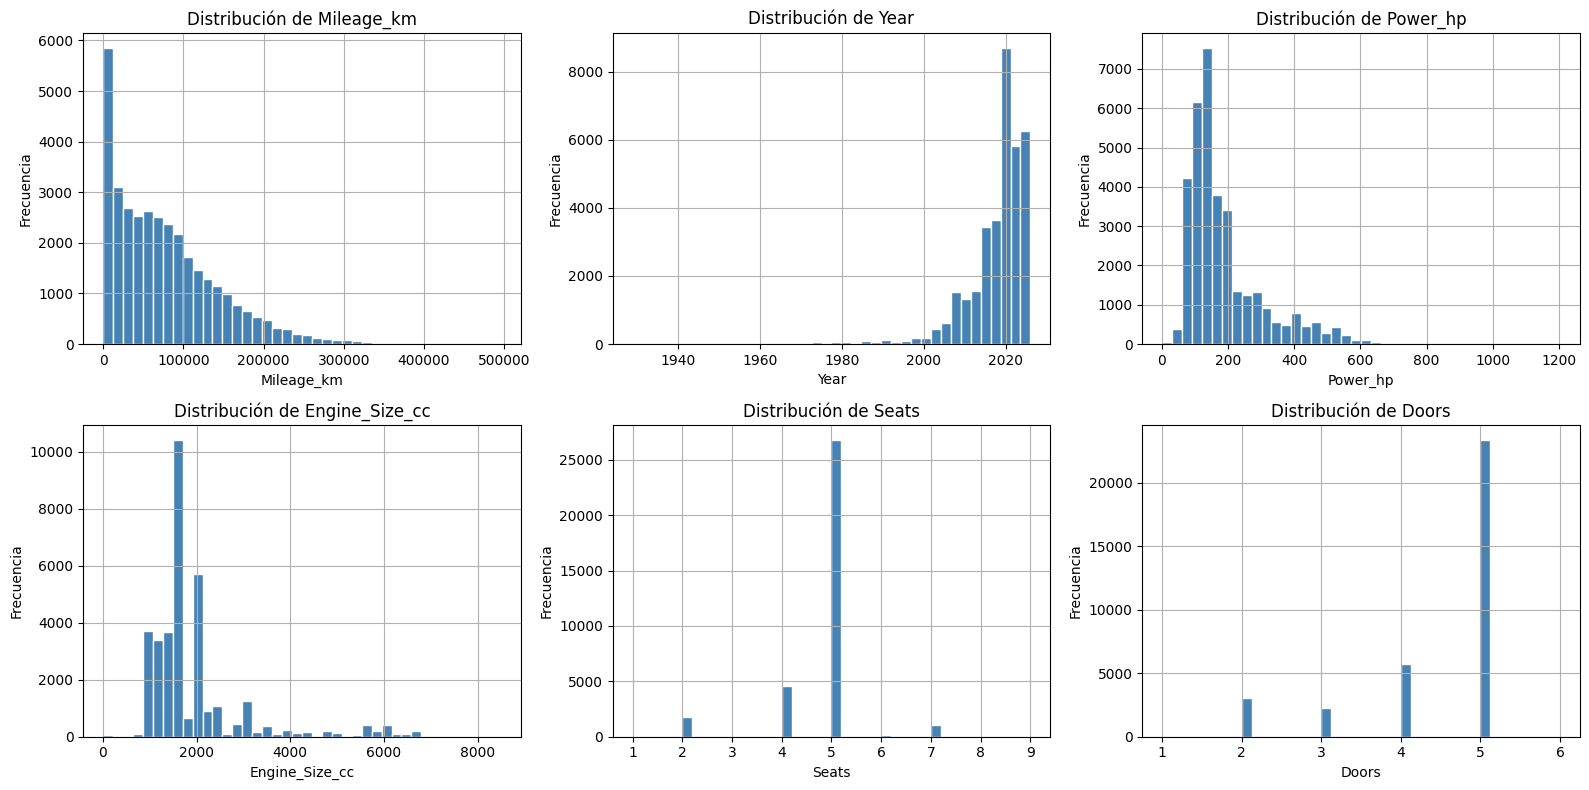

In [56]:
num_cols = ['Mileage_km', 'Year', 'Power_hp', 'Engine_Size_cc', 'Seats', 'Doors']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Análisis univariante — Variables numéricas

- **Mileage_km:** distribución sesgada a la derecha, la mayoría de coches tiene menos de 100.000 km. ( Sospecho que en España es diferente)
- **Year:** el mercado se concentra en coches recientes (2015-2024), con una cola de clásicos que llega hasta los años 40. 
- **Power_hp:** mayoría entre 100 y 200cv, tiene sentido.
- **Engine_Size_cc:** predominan motores entre 1.000 y 2.000cc, lo esperado. Motores pequeños y eficientes.
- **Seats y Doors:** variables muy concentradas — esperable lo normal 5, o quizá 4 plazas. La mayoría 5.

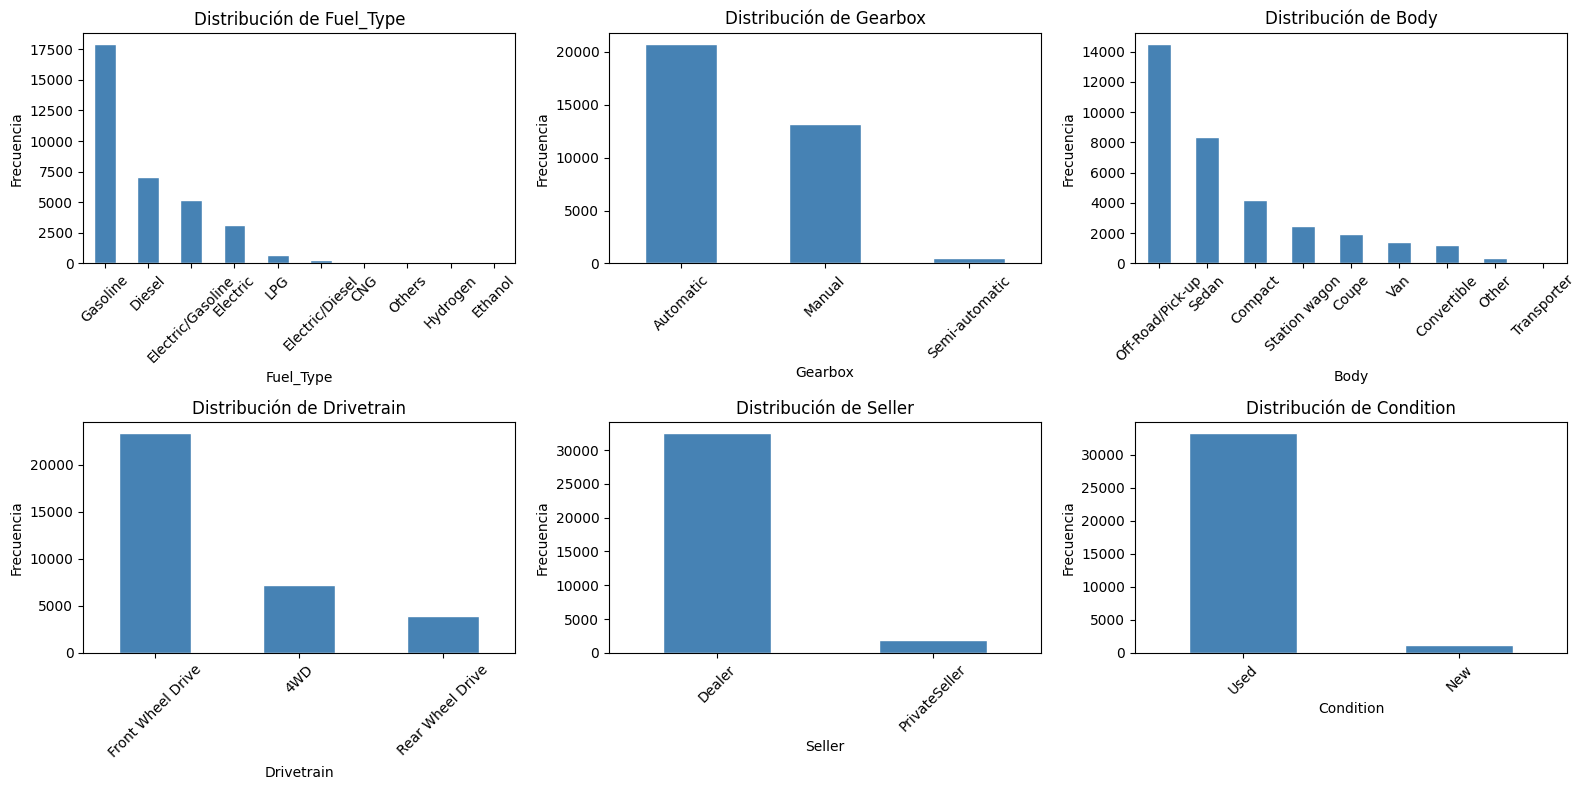

In [57]:
cat_cols = ['Fuel_Type', 'Gearbox', 'Body', 'Drivetrain', 'Seller', 'Condition']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Análisis univariante — Variables categóricas

- **Fuel_Type:** gasolina domina pero el eléctrico e híbrido ya tienen presencia significativa.
- **Gearbox:** el automático supera al manual, impulsado también por la presencia de híbridos y eléctricos.
- **Body:** los SUV y Off-Road lideran claramente — el mercado europeo se ha rendido al SUV. Es la moda, aunque no lo mejor.
- **Drivetrain:** tracción delantera abrumadoramente mayoritaria, coherente con el mercado general.
- **Seller:** los concesionarios dominan sobre los particulares, típico de plataformas como AutoScout24.
- **Condition:** realmente, el dataset es de mercado de coches usados.

## Análisis bivariante

Exploramos las relaciones entre las variables numéricas y el target `Price`.

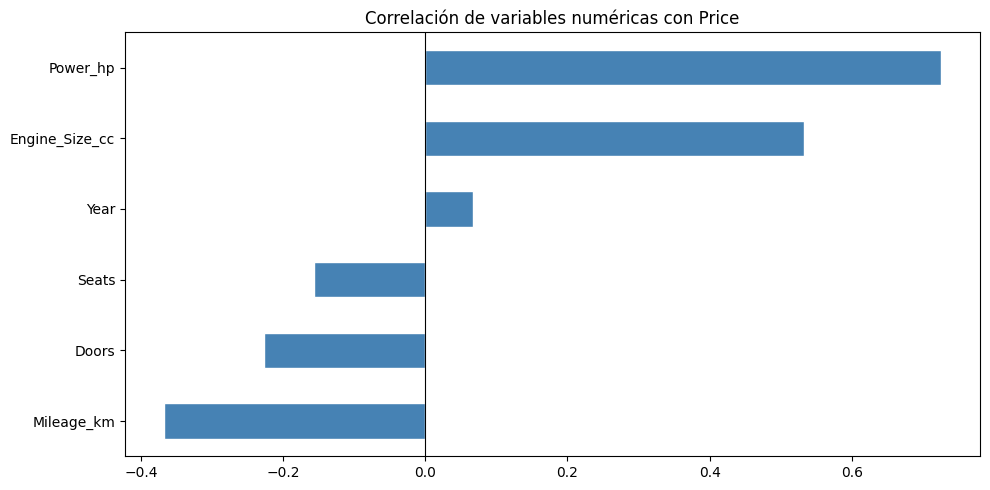

In [58]:
num_cols = ['Mileage_km', 'Year', 'Power_hp', 'Engine_Size_cc', 'Seats', 'Doors']

correlaciones = df[num_cols + ['Price']].corr()['Price'].drop('Price').sort_values()

correlaciones.plot(kind='barh', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.title('Correlación de variables numéricas con Price')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Correlación de variables numéricas con el precio

`Power_hp` es con diferencia la variable con mayor correlación con el precio (~0.7) — a más potencia, más precio, tiene sentido. Y apoya la hipótesis #6

Le sigue `Engine_Size_cc` (~0.5), coherente con que motores más grandes suelen ir asociados a coches de gama más alta, y coches con más potencia, refuerza la anterior.

`Mileage_km` muestra correlación negativa moderada (~-0.35) — más kilómetros, menos precio — aunque menor de lo que cabría esperar a priori.

`Year` sorprende con una correlación positiva muy débil — la antigüedad del coche influye menos de lo esperado en el precio, los compradores valoran otras cosas, y puede que los clásicos compensen la correlación.

`Seats` y `Doors` presentan correlación negativa — los coches con más plazas y puertas tienden a ser más baratos, lo que apunta a que furgonetas y familiares grandes están por debajo de la media de precio en este dataset.

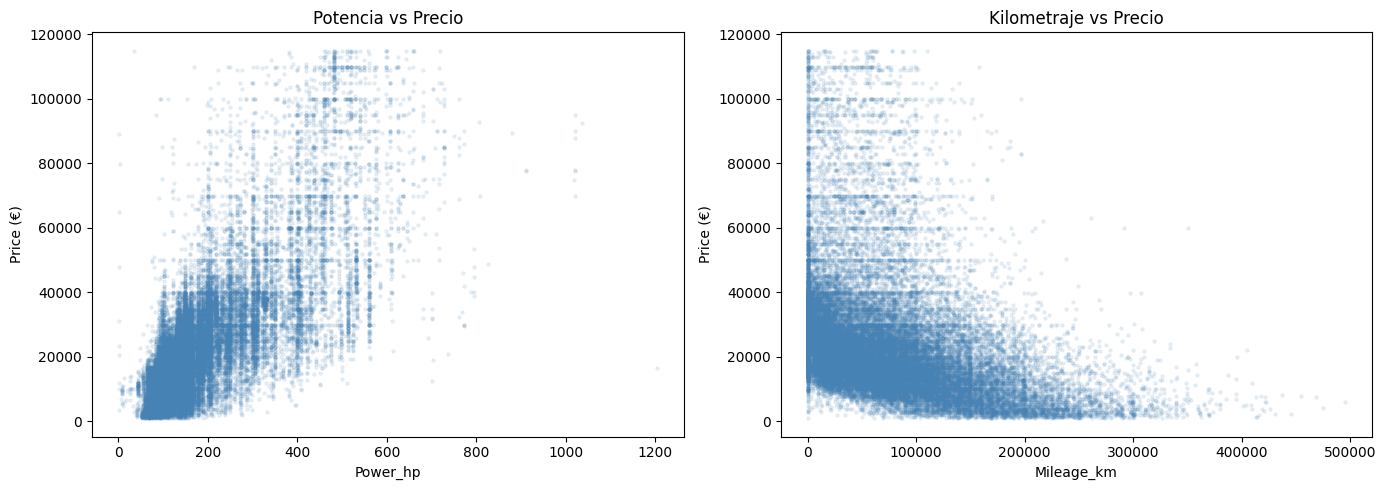

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Power_hp'], df['Price'], alpha=0.1, color='steelblue', s=5)
axes[0].set_title('Potencia vs Precio')
axes[0].set_xlabel('Power_hp')
axes[0].set_ylabel('Price (€)')

axes[1].scatter(df['Mileage_km'], df['Price'], alpha=0.1, color='steelblue', s=5)
axes[1].set_title('Kilometraje vs Precio')
axes[1].set_xlabel('Mileage_km')
axes[1].set_ylabel('Price (€)')

plt.tight_layout()
plt.show()

### Potencia y kilometraje vs precio

La relación entre potencia y precio es positiva y clara — a más cv, más precio — aunque con dispersión alta, especialmente en el rango 200-600cv donde conviven coches de muy distinto valor. A partir de 400cv los precios se disparan.

El kilometraje muestra una relación negativa en forma de abanico: los coches con pocos kilómetros tienen precios muy dispersos (los hay baratos y muy caros), mientras que a más de 200.000 km los precios convergen hacia valores bajos. La relación existe pero no es lineal, lo que sugiere que el kilometraje por sí solo no explica el precio.

### Precio medio por variable categórica

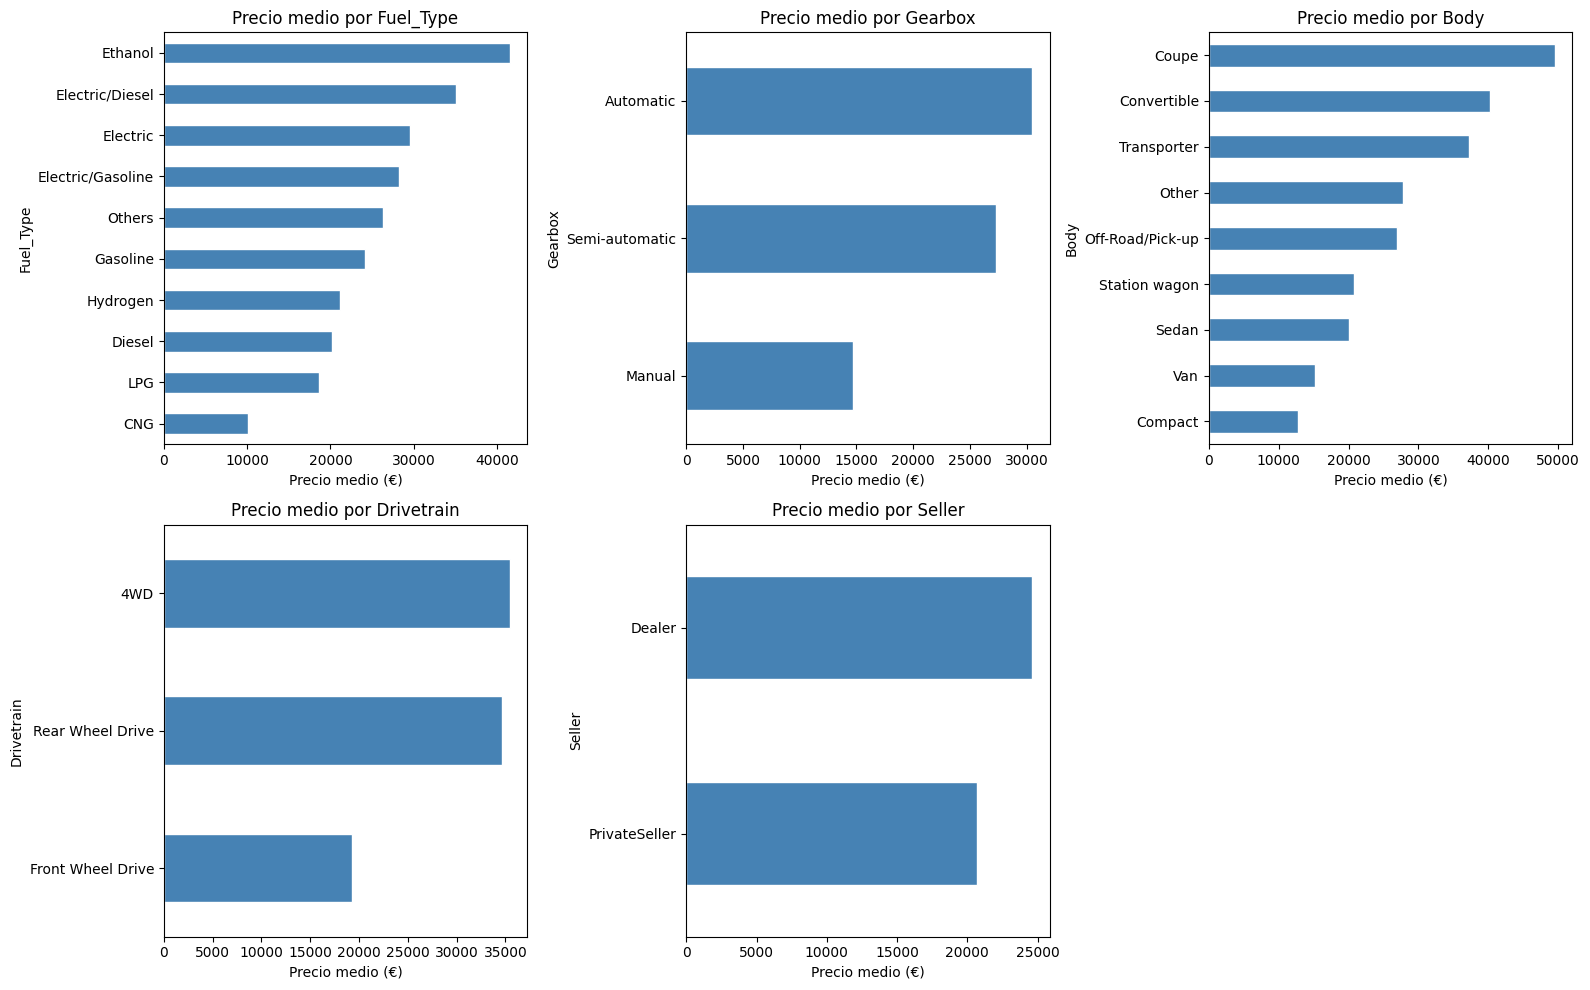

In [60]:
cat_cols = ['Fuel_Type', 'Gearbox', 'Body', 'Drivetrain', 'Seller']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df.groupby(col)['Price'].mean().sort_values().plot(
        kind='barh', ax=axes[i], color='steelblue', edgecolor='white'
    )
    axes[i].set_title(f'Precio medio por {col}')
    axes[i].set_xlabel('Precio medio (€)')

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

### Precio medio por variable categórica

- **Fuel_Type:** el etanol aparece con el precio medio más alto pero con muy pocos registros — es un sesgo de muestra, no una tendencia real del mercado. Los eléctricos e híbridos enchufables sí muestran precios elevados de forma representativa. El diesel ha caído por debajo de la gasolina, reflejo de su pérdida de valor en el mercado europeo actual. CNG y LPG son los combustibles más baratos.
- **Gearbox:** el automático casi dobla en precio al manual — el cambio automático va asociado a gama media-alta.
- **Body:** coupe y descapotable son los más caros. Los compactos los más baratos. Las furgonetas de trabajo tienen valor elevado.
- **Drivetrain:** 4WD y tracción trasera muy por encima de la delantera — coherente con que SUV y deportivos son más caros.
- **Seller:** los concesionarios venden unos 4.000€ más caro de media que los particulares. Bastante diferencia.

### Análisis por país

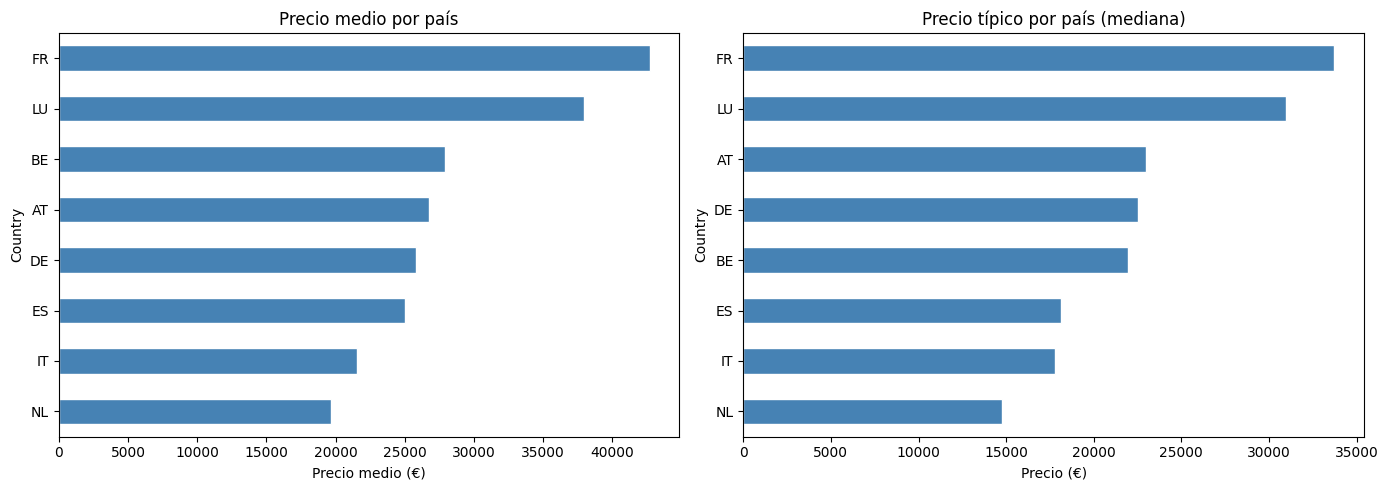

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Country')['Price'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Precio medio por país')
axes[0].set_xlabel('Precio medio (€)')

df.groupby('Country')['Price'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Precio típico por país (mediana)')
axes[1].set_xlabel('Precio (€)')

plt.tight_layout()
plt.show()

### Precio por país

Francia lidera tanto en precio medio como en mediana de forma destacada — posiblemente por un sesgo del dataset con más coches de gama alta en los anuncios franceses. Luxemburgo ocupa el segundo puesto, sí tiene sentido en un país con mayor renta, de los más de Europa.

España e Italia son los mercados más baratos junto con Holanda, lo que confirma la hipótesis 2 — sí existen diferencias significativas de precio entre países. Alemania, pese a ser el mayor mercado europeo de automoción, se sitúa en la media. 

La brecha entre precio medio y mediana en Francia sugiere la presencia de coches muy caros que distorsionan la media hacia arriba.

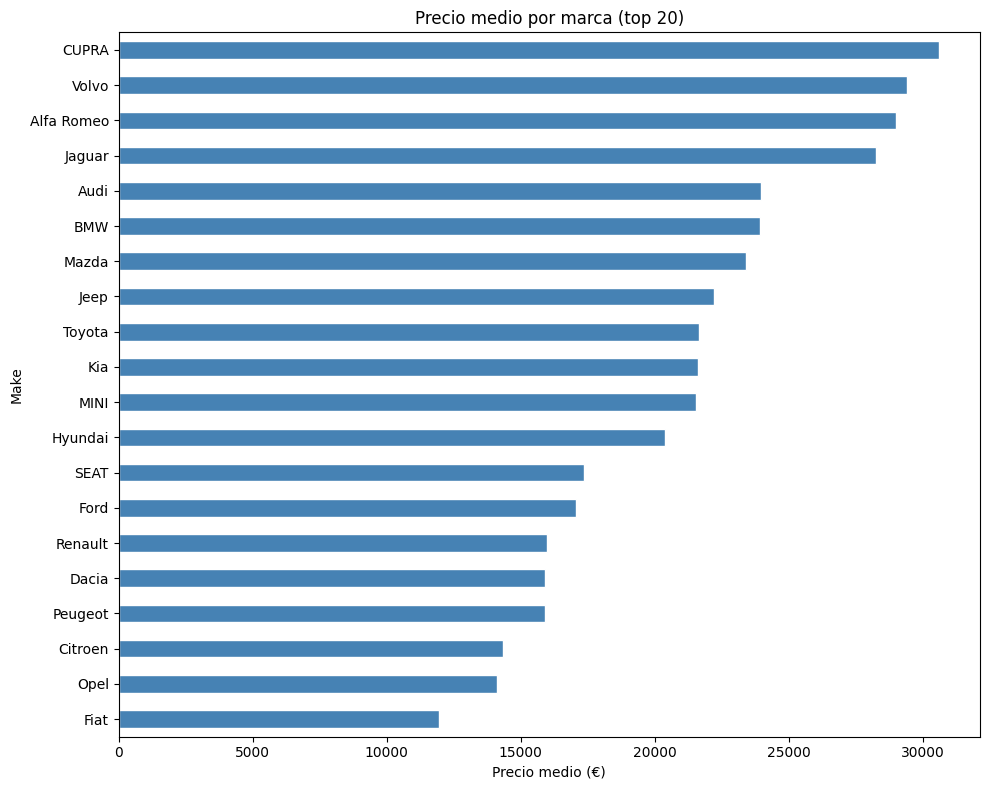

In [62]:
# Precio medio por marca (obviando marcas más exclusivas y raras)
top_makes = df['Make'].value_counts().head(20).index

df[df['Make'].isin(top_makes)].groupby('Make')['Price'].mean().sort_values().plot(
    kind='barh', figsize=(10, 8), color='steelblue', edgecolor='white'
)
plt.title('Precio medio por marca (top 20)')
plt.xlabel('Precio medio (€)')
plt.tight_layout()
plt.show()

### Precio medio por marca

CUPRA lidera el precio medio entre las 20 marcas más frecuentes del dataset — resultado sorprendente pero coherente con su posicionamiento deportivo de gama alta desde su nacimiento como marca independiente. Volvo, Alfa Romeo y Jaguar completan el podio de marcas premium.

Audi y BMW aparecen prácticamente empatadas, confirmando su rivalidad histórica en el segmento premium masivo. En el extremo opuesto, Fiat y Opel son las marcas más baratas, coherente con su enfoque en el mercado de acceso.

## Análisis multivariante

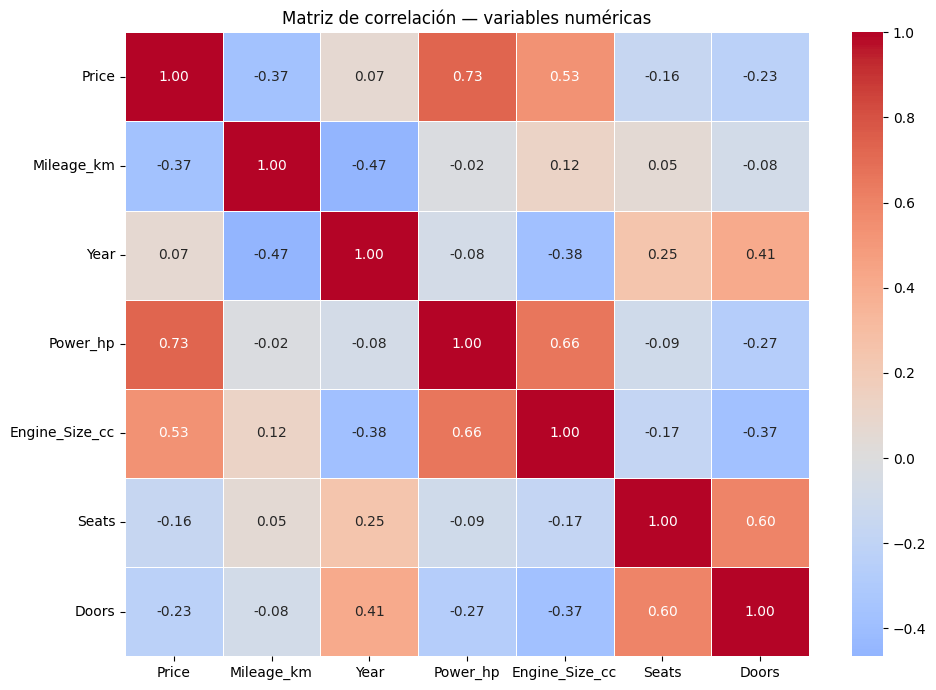

In [63]:
# Heatmap de correlación
num_cols = ['Price', 'Mileage_km', 'Year', 'Power_hp', 'Engine_Size_cc', 'Seats', 'Doors']

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

### Matriz de correlación

El heatmap confirma que `Power_hp` es la variable con mayor correlación con el precio (0.73), seguida de `Engine_Size_cc` (0.53). Ambas están además muy correlacionadas entre sí (0.66), lo que indica cierta redundancia — motores más grandes suelen tener más potencia.

`Mileage_km` correlaciona negativamente con el precio (-0.37) y también con el año (-0.47) — los coches más nuevos tienen menos kilómetros, y son más caros, normal.

`Seats` y `Doors` están correlacionadas entre sí (0.60) y ambas negativamente con el precio — variables de poca utilidad predictiva individual.

`Year` apenas correlaciona con el precio (0.07) — la antigüedad del coche no explica bien el precio por sí sola en este dataset. Muchos clásicos.

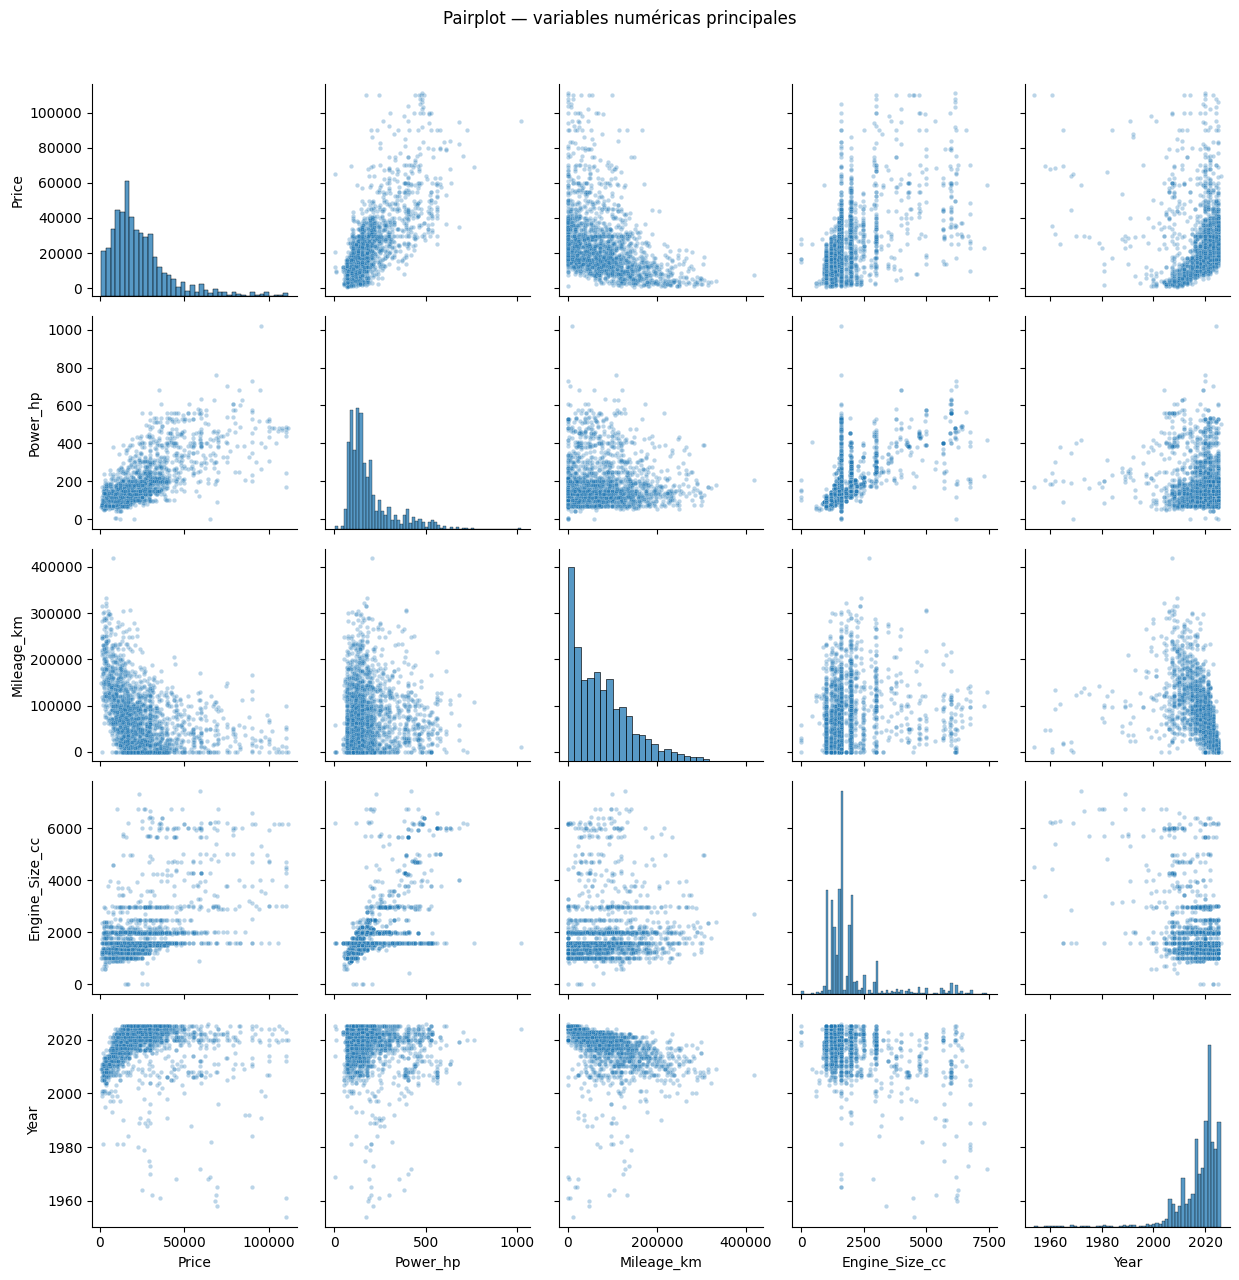

In [64]:
#Pairplot de variables principales
sns.pairplot(
    df[['Price', 'Power_hp', 'Mileage_km', 'Engine_Size_cc', 'Year']].sample(2000, random_state=42),
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='hist'
)
plt.suptitle('Pairplot — variables numéricas principales', y=1.02)
plt.tight_layout()
plt.show()

### Pairplot

El pairplot confirma visualmente las relaciones detectadas en la matriz de correlación. Destaca la relación positiva clara entre `Power_hp` y `Price`, la relación negativa de `Mileage_km` con el precio, y la escasa relación del `Year` con el resto de variables salvo el kilometraje.

## Verificación de hipótesis

Contrastamos las hipótesis planteadas al inicio con los hallazgos del EDA.

### Hipótesis descartadas

**Hipótesis 5 — Número de propietarios anteriores:** descartada por falta de datos. La columna `Previous_Owners` tenía un 44% de missings y además es un dato que los vendedores pueden manipular fácilmente en los anuncios. No es una fuente fiable para extraer conclusiones.

**Hipótesis 6 — La potencia es el factor técnico con mayor correlación con el precio:** confirmada y cerrada en el análisis multivariante. La correlación de `Power_hp` con `Price` es de 0.73, la más alta de todas las variables numéricas con diferencia. No requiere análisis adicional.


### Hipótesis 1 — ¿Influye más el kilometraje o la antigüedad en el precio?

**Hipótesis:** El kilometraje deprecia el precio más que la antigüedad del vehículo.

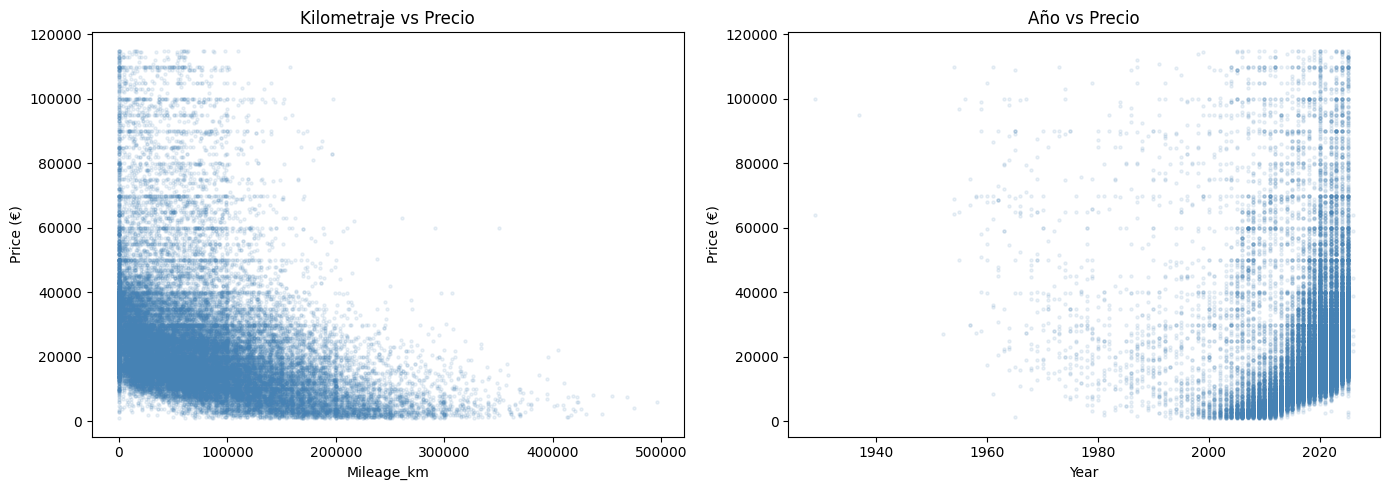

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Mileage_km'], df['Price'], alpha=0.1, color='steelblue', s=5)
axes[0].set_title('Kilometraje vs Precio')
axes[0].set_xlabel('Mileage_km')
axes[0].set_ylabel('Price (€)')

axes[1].scatter(df['Year'], df['Price'], alpha=0.1, color='steelblue', s=5)
axes[1].set_title('Año vs Precio')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Price (€)')

plt.tight_layout()
plt.show()

**Resultado: CONFIRMADA.** El scatter de kilometraje vs precio muestra una tendencia negativa clara en forma de abanico — a más kilómetros, los precios caen y se concentran en valores bajos. El año en cambio muestra una nube muy dispersa sin tendencia clara, especialmente porque los clásicos de los años 40-80 mantienen precios altos que rompen la lógica de "más antiguo, más barato".

La correlación confirma los visual: `Mileage_km` correlaciona -0.37 con el precio frente al 0.07 del `Year`. El kilometraje es mejor predictor del precio que la antigüedad en este dataset.

### Hipótesis 2 — ¿Hay diferencias significativas de precio entre países?

**Hipótesis:** Existen diferencias significativas de precio entre países para características similares de vehículo.

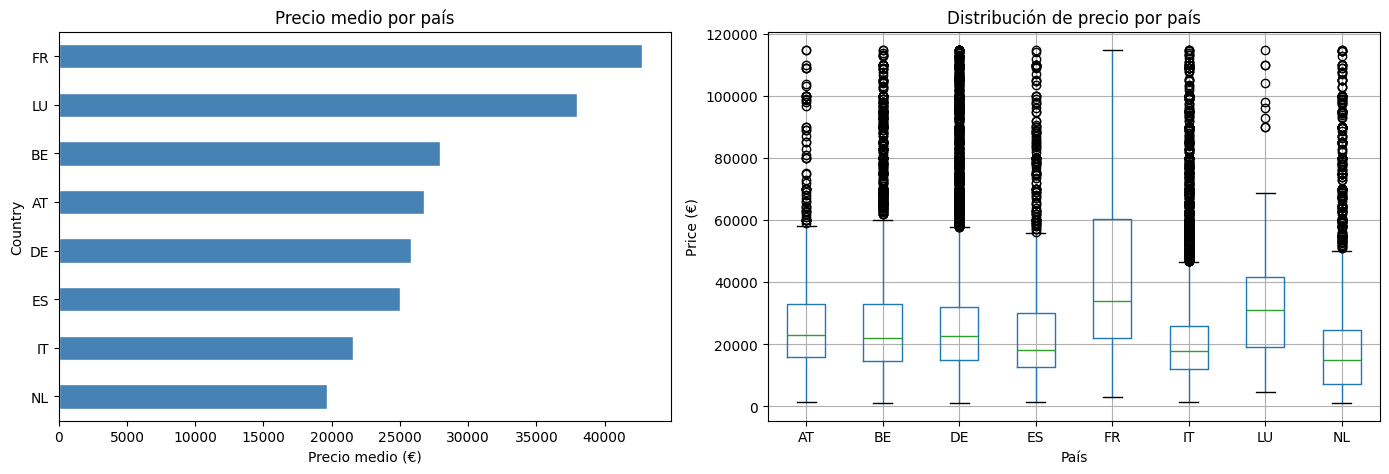

In [66]:
# Precio medio por país con boxplot para ver la dispersión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Country')['Price'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Precio medio por país')
axes[0].set_xlabel('Precio medio (€)')

df.boxplot(column='Price', by='Country', ax=axes[1], figsize=(14, 5))
axes[1].set_title('Distribución de precio por país')
axes[1].set_xlabel('País')
axes[1].set_ylabel('Price (€)')
plt.suptitle('')

plt.tight_layout()
plt.show()

**Resultado: CONFIRMADA.** Las diferencias entre países son claras y consistentes. Francia y Luxemburgo tienen precios significativamente más altos que el resto, mientras que Holanda e Italia son los mercados más baratos.

El boxplot revela además que Francia tiene una dispersión enorme — la caja es mucho más amplia que el resto, confirmando que hay una mezcla de coches baratos y muy caros. Luxemburgo en cambio tiene precios altos pero más homogéneos.

España se sitúa en una posición intermedia-baja, por debajo de Alemania, Bélgica y Austria pero por encima de Italia y Holanda. Esto es relevante para luego el modelo — el mercado español tiene su propia lógica de precios.

### Hipótesis 3 — ¿Qué marcas retienen mejor el valor?

**Hipótesis:** Existen diferencias significativas de precio medio entre marcas, con las marcas premium reteniendo mejor el valor.

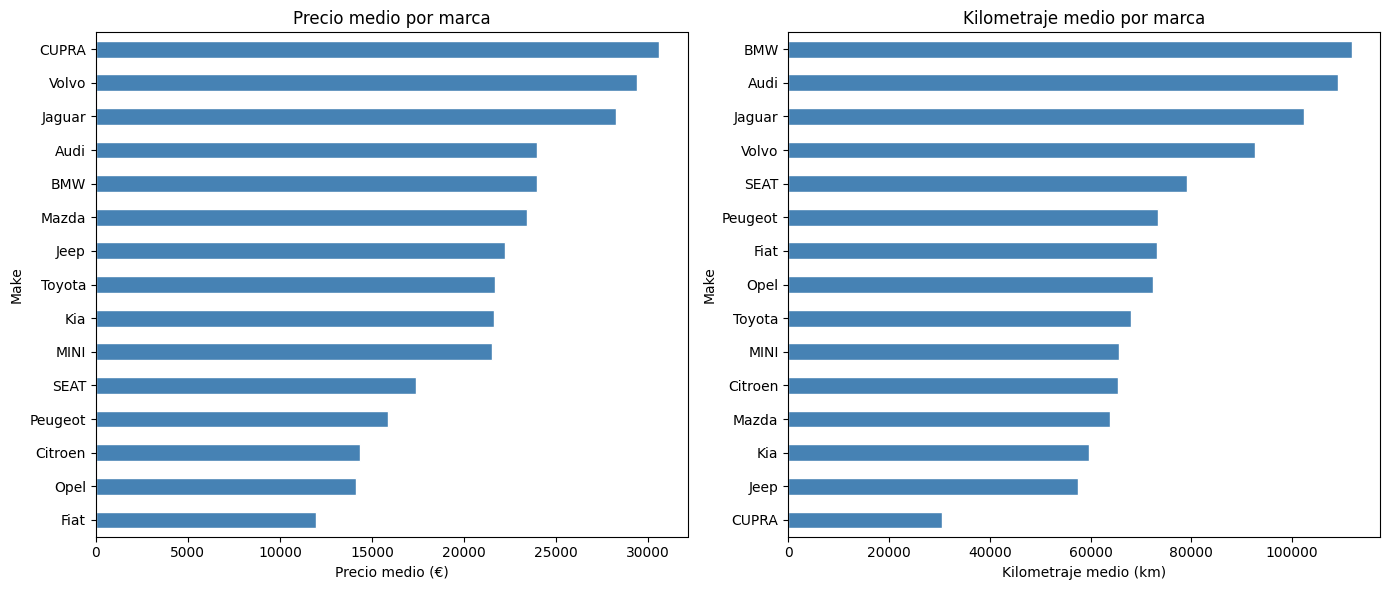

In [67]:
# Precio medio vs kilometraje medio por marca, para ver depreciación
top_makes = df['Make'].value_counts().head(15).index

marca_stats = df[df['Make'].isin(top_makes)].groupby('Make').agg(
    precio_medio=('Price', 'mean'),
    km_medio=('Mileage_km', 'mean')
).sort_values('precio_medio', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

marca_stats['precio_medio'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Precio medio por marca')
axes[0].set_xlabel('Precio medio (€)')

marca_stats['km_medio'].sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Kilometraje medio por marca')
axes[1].set_xlabel('Kilometraje medio (km)')

plt.tight_layout()
plt.show()

**Resultado: CONFIRMADA.** Las marcas premium retienen mejor el valor. CUPRA lidera en precio, pero con el kilometraje más bajo. BMW y Audi destacan por mantener precios altos a pesar de tener el kilometraje medio más elevado, lo que demuestra menor depreciación, frente al uso.

En el extremo opuesto, Fiat y Opel tienen los precios más bajos con kilometrajes similares al resto — se deprecian más rápido. Toyota y Kia ofrecen una buena relación precio/kilometraje, coherente con su reputación de fiabilidad y bajo coste de mantenimiento.

### Hipótesis 4 — ¿El tipo de combustible afecta al precio de forma significativa?

**Hipótesis:** Los vehículos eléctricos e híbridos tienen un precio medio significativamente superior a los de combustión tradicional.

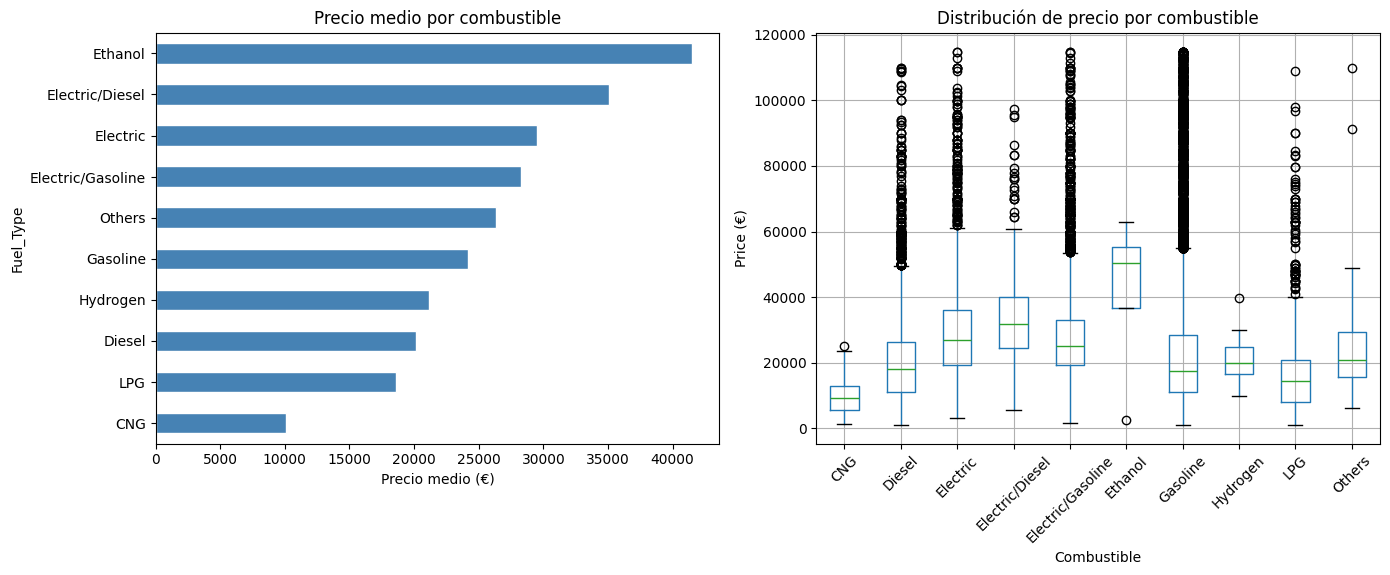

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df.groupby('Fuel_Type')['Price'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Precio medio por combustible')
axes[0].set_xlabel('Precio medio (€)')

df.boxplot(column='Price', by='Fuel_Type', ax=axes[1])
axes[1].set_title('Distribución de precio por combustible')
axes[1].set_xlabel('Combustible')
axes[1].set_ylabel('Price (€)')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

**Resultado: CONFIRMADA PARCIALMENTE.** Los vehículos eléctricos e híbridos tienen un precio medio superior a los de combustión. El diesel ha caído claramente por debajo de la gasolina, cada vez se venden menos y son más viejos y con más kms los que hay en el mercado.

El etanol aparece como el más caro en precio medio pero es un sesgo de muestra — hay muy pocos registros y corresponden a modelos concretos de gama alta.

El boxplot revela que el eléctrico tiene una dispersión muy alta — conviven coches eléctricos baratos de acceso (Dacia Spring, MG) con eléctricos premium (Tesla, BMW i). El diesel y la gasolina tienen distribuciones más homogéneas y concentradas en precios bajos-medios.

CNG y LPG son los combustibles más baratos con diferencia — son opciones de bajo coste asociadas a vehículos de gama baja.

## Conclusiones del EDA

### Resumen de hipótesis

| Hipótesis | Resultado |
|-----------|-----------|
| H1 — El kilometraje deprecia más el precio que la antigüedad | Confirmada |
| H2 — Existen diferencias significativas de precio entre países | Confirmada |
| H3 — Las marcas premium retienen mejor el valor | Confirmada |
| H4 — Los eléctricos e híbridos tienen precio superior a los de combustión | Confirmada parcialmente |
| H5 — El número de propietarios deprecia el precio | Descartada por falta de datos |
| H6 — La potencia es el factor técnico con mayor correlación con el precio | Confirmada en el análisis multivariante |

### Hallazgos principales

- `Power_hp` es la variable más predictiva del precio (correlación 0.73)
- El mercado español tiene precios por debajo de la media europea
- Las marcas premium (CUPRA, Volvo, Jaguar, Audi, BMW) retienen mejor el valor
- El diesel se ha devaluado respecto a la gasolina en el mercado europeo actual
- El año de matriculación apenas predice el precio — los clásicos rompen esa lógica
- El 76% del mercado se concentra entre 5.000 y 35.000€

## Paso 7: Modelado ML — Foco en España

### ¿Qué vamos a hacer y por qué?

El EDA nos ha dado una visión completa del mercado europeo de segunda mano. Ahora nos centramos en España para construir un modelo capaz de predecir el precio de un coche a partir de sus características.

El problema es de **regresión supervisada** — tenemos ejemplos reales de coches con su precio conocido (`Price`), y queremos que el modelo aprenda la relación entre las características del coche y su precio para poder predecir el precio de coches nuevos que no ha visto.

### ¿Qué van a "ver" los modelos?

Los algoritmos de ML no entienden texto, solo números. Por eso necesitamos transformar el dataset:

- **Variables categóricas** como `Fuel_Type` o `Gearbox` se convierten en columnas de 0s y 1s mediante encoding
- **Variables numéricas** como `Mileage_km` o `Power_hp` se escalan para que todas estén en rangos similares — algunos algoritmos son sensibles a las diferencias de escala
- **Variables con demasiados valores únicos** como `Model` (268 valores) se descartan — encodearlas generaría 268 columnas nuevas con muy pocos datos cada una, lo que añade ruido y empeora el modelo. Esto se llama alta cardinalidad.

### ¿Cómo sabremos si el modelo es bueno?

Usaremos el **MAE (Mean Absolute Error)** como métrica principal — el error medio en euros entre el precio predicho y el precio real. Es la métrica más intuitiva para este problema: si el MAE es 2.000€, el modelo se equivoca de media 2.000€ por coche.

### Pasos que seguiremos

1. Filtrar España y hacer split Train/Test
2. Preprocesado: encoding de categóricas y escalado de numéricas
3. Baseline — modelo simple de referencia
4. Comparativa de varios modelos con validación cruzada
5. Optimización de hiperparámetros del modelo ganador
6. Evaluación final contra Test
7. Análisis de errores y conclusiones
8. Guardar el modelo en disco

In [69]:
# Nos quedamos con el mercado español
df_es = df[df['Country'] == 'ES'].copy()
print(f"Registros España: {df_es.shape[0]}")
df_es['Price'].describe().apply(lambda x: f"{x:,.0f} €")

Registros España: 1373


count      1,373 €
mean      25,035 €
std       20,382 €
min        1,410 €
25%       12,600 €
50%       18,150 €
75%       29,990 €
max      114,900 €
Name: Price, dtype: str

## Paso 8: Split Train/Test

In [70]:
target = 'Price'

X = df_es.drop(columns=[target, 'Country'])  # Country ya no aporta, todos son ES
y = df_es[target]

# Split antes de cualquier preprocesado — así el test nunca "ve" el entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (1098, 17)
Test:  (275, 17)


In [71]:
X_train.dtypes
# vemos columnas

Make                        str
Model                       str
Body                        str
Mileage_km                int64
Year                    float64
Condition                   str
Fuel_Type                   str
Drivetrain                  str
Gearbox                     str
Power_hp                  int64
Engine_Size_cc          float64
Seats                   float64
Doors                   float64
Upholstery                  str
Full_Service_History       bool
Non_Smoker_Vehicle         bool
Seller                      str
dtype: object

In [72]:
# Vemos si hay nuevos, supongo que pocos o ninguno
X_train['Condition'].value_counts()

Condition
Used    1090
New        8
Name: count, dtype: int64

## Paso 9: Preprocesado y Feature Engineering

Preparamos los datos para el modelado. `Condition` se elimina — 99.3% de los registros españoles son usados, no aporta información.

In [73]:
X_train = X_train.drop(columns=['Condition'])
X_test = X_test.drop(columns=['Condition'])

In [74]:
# Valores únicos
cat_cols = ['Make', 'Model', 'Body', 'Fuel_Type', 'Drivetrain', 'Gearbox', 'Upholstery', 'Seller']

for col in cat_cols:
    print(f"{col}: {X_train[col].nunique()} valores únicos")

Make: 39 valores únicos
Model: 268 valores únicos
Body: 7 valores únicos
Fuel_Type: 5 valores únicos
Drivetrain: 3 valores únicos
Gearbox: 2 valores únicos
Upholstery: 1 valores únicos
Seller: 1 valores únicos


In [75]:
# Son constantes no aportan nada
X_train = X_train.drop(columns=['Upholstery', 'Seller'])
X_test = X_test.drop(columns=['Upholstery', 'Seller'])

In [76]:
# Demasiada cardinalidad
X_train = X_train.drop(columns=['Model'])
X_test = X_test.drop(columns=['Model'])

In [77]:
X_train.shape

(1098, 13)

In [78]:
# Encoding de categorías
cat_cols = ['Make', 'Body', 'Fuel_Type', 'Drivetrain', 'Gearbox']

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos columnas por si hay categorías en test que no están en train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (1098, 59)
Test:  (275, 59)


In [79]:
# Escalado de numércicas
num_cols = ['Mileage_km', 'Year', 'Power_hp', 'Engine_Size_cc', 'Seats', 'Doors']

scaler = StandardScaler()
# fit_transform en train, solo transform en test — el scaler aprende solo de los datos de entrenamiento
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Paso 10: Baseline

Establecemos un modelo de referencia mínimo. Usamos la media del precio de train como predicción para todos los coches — si nuestros modelos no superan esto, mal.

In [80]:
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Precio medio train: {y_train.mean():,.0f} €")
print(f"MAE baseline: {baseline_mae:,.0f} €")

Precio medio train: 25,009 €
MAE baseline: 13,769 €


El baseline predice siempre el precio medio de train (25.009€) para cualquier coche. El MAE resultante es de 13.769€ — cualquier modelo que no mejore este número no sirve para nada.

In [81]:
# Comparativa de modelos,
modelos = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}
# Cada modelo se prueba 5 veces con distintas partes del train, el MAE es la media
resultados = {}
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    resultados[nombre] = -scores.mean()
    print(f"{nombre}: {-scores.mean():,.0f} €")

LinearRegression: 5,876 €
Ridge: 5,851 €
DecisionTree: 6,354 €
RandomForest: 4,662 €
GradientBoosting: 4,929 €


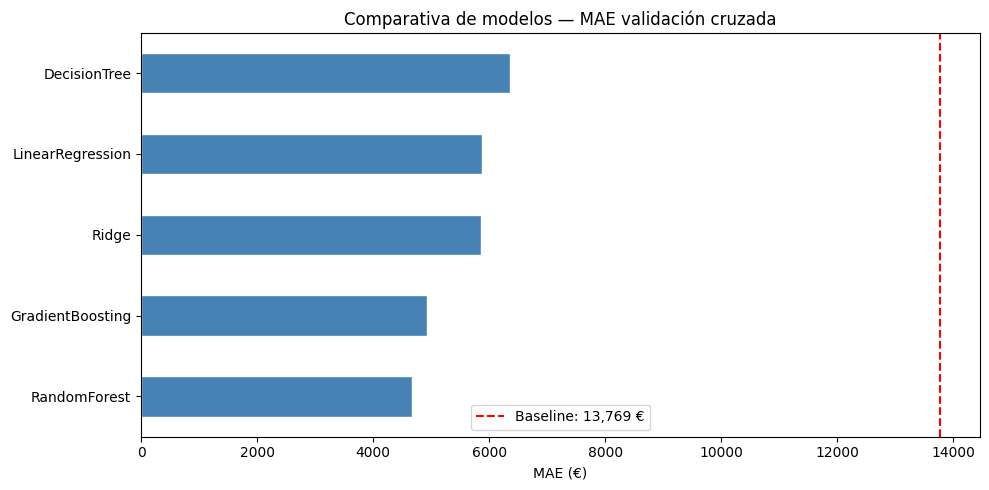

In [82]:
# Visualizamos
resultados_df = pd.Series(resultados).sort_values()

resultados_df.plot(kind='barh', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.axvline(baseline_mae, color='red', linestyle='--', label=f'Baseline: {baseline_mae:,.0f} €')
plt.title('Comparativa de modelos — MAE validación cruzada')
plt.xlabel('MAE (€)')
plt.legend()
plt.tight_layout()
plt.show()

## Paso 11: Comparativa de modelos

Todos los modelos mejoran ampliamente el baseline de 13.769€. RandomForest obtiene el mejor MAE en validación cruzada (4.662€), seguido de GradientBoosting (4.929€). Los modelos lineales se quedan en torno a 5.850€ y el árbol de decisión simple es el peor de los cinco.

Seleccionamos **RandomForest** como modelo a optimizar.

## Paso 12: Optimización de hiperparámetros — RandomForest

In [83]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf, param_grid, cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, # usa todos los núcleos disponibles del procesador para optimizar
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor MAE: {-grid_search.best_score_:,.0f} €")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor MAE: 4,660 €


In [84]:
rf_default = RandomForestRegressor()
print(f"n_estimators por defecto: {rf_default.n_estimators}")
print(f"max_depth por defecto: {rf_default.max_depth}")
print(f"min_samples_split por defecto: {rf_default.min_samples_split}")
print(f"min_samples_leaf por defecto: {rf_default.min_samples_leaf}")

n_estimators por defecto: 100
max_depth por defecto: None
min_samples_split por defecto: 2
min_samples_leaf por defecto: 1


La mejora sobre el modelo sin optimizar es mínima (de 4.662€ a 4.660€), lo que indica que el modelo ya estaba bien ajustado de serie con los datos disponibles. El único ajuste real es usar más árboles.

## Paso 13: Evaluación final contra Test

In [85]:
mejor_modelo = grid_search.best_estimator_
y_pred = mejor_modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²:   {r2:.3f}")

MAE:  4,344 €
RMSE: 7,878 €
R²:   0.850


## Evaluación final contra Test

| Métrica | Valor |
|---------|-------|
| MAE | 4.344 € |
| RMSE | 7.878 € |
| R² | 0.850 |

El modelo generaliza bien — el MAE en test (4.344€) es incluso mejor que en validación cruzada (4.660€), descartando overfitting. El R² de 0.85 indica que el modelo explica el 85% de la variabilidad del precio, un buen resultado para un dataset de 1.373 registros.

La diferencia entre MAE y RMSE sugiere que hay algunos coches donde el error es considerable — lo analizamos a continuación.

## Paso 14: Análisis de errores

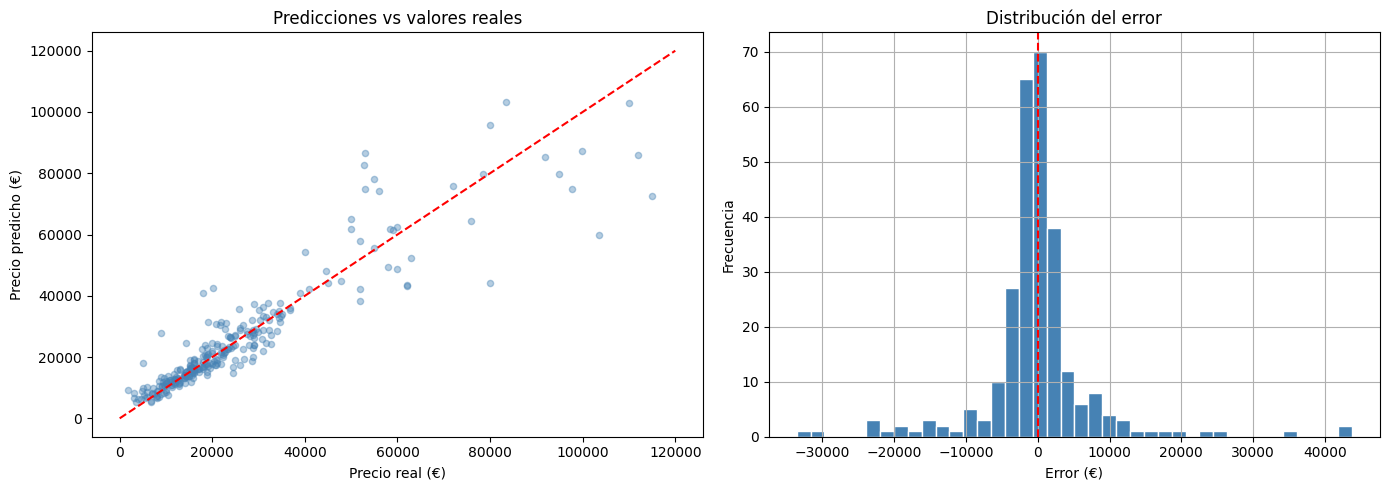

In [86]:
errores = pd.DataFrame({
    'y_real': y_test.values,
    'y_pred': y_pred,
    'error': y_test.values - y_pred,
    'error_abs': np.abs(y_test.values - y_pred)
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(errores['y_real'], errores['y_pred'], alpha=0.4, color='steelblue', s=20)
axes[0].plot([0, 120000], [0, 120000], color='red', linestyle='--')
axes[0].set_title('Predicciones vs valores reales')
axes[0].set_xlabel('Precio real (€)')
axes[0].set_ylabel('Precio predicho (€)')

errores['error'].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución del error')
axes[1].set_xlabel('Error (€)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Análisis de errores

El scatter de predicciones vs valores reales muestra un buen ajuste en el rango 0-40.000€, donde se concentra la mayoría del mercado español. A partir de 50.000€ el modelo tiende a subestimar el precio — hay pocos coches de gama alta en el dataset español (1.373 registros en total) y el modelo no tiene suficientes ejemplos para aprender bien ese segmento.

La distribución del error está centrada en 0 y es aproximadamente simétrica — el modelo no tiene sesgo sistemático hacia sobreestimar ni subestimar. Los errores extremos (±30.000-40.000€) corresponden precisamente a los coches de gama alta donde los datos son escasos.

### Posibles mejoras

**Mejora 1 — Más datos españoles**  
Con solo 1.373 registros el modelo tiene poco donde aprender, especialmente en gama alta. Haciendo scraping de Coches.net o Wallapop conseguiría mucho más volumen y representaría mejor el mercado real español.

**Mejora 2 — Recuperar el modelo del coche**  
Tuve que descartarlo porque había 268 modelos distintos y eso generaba demasiadas columnas. Con Target Encoding — sustituir cada modelo por su precio medio histórico — se podría incluir sin ese problema. Un Golf GTI no vale lo mismo que un Golf base, y el modelo debería saberlo.

**Mejora 3 — Antigüedad del anuncio**  
Si un coche lleva 6 meses en el anuncio sin venderse, algo pasa — precio alto, problema oculto, o simplemente poca demanda. Es una señal de mercado real que este dataset no recoge pero que se podría obtener haciendo scraping con fecha de publicación.

## Paso 15: Guardado del modelo

In [87]:
os.makedirs('src/models', exist_ok=True)

with open('src/models/rf_usedcars_spain.pkl', 'wb') as f:
    pickle.dump(mejor_modelo, f)

print("Modelo guardado en src/models/rf_usedcars_spain.pkl")

Modelo guardado en src/models/rf_usedcars_spain.pkl


## Conclusiones finales

El modelo RandomForest entrenado sobre el mercado español de segunda mano obtiene un MAE de 4.344€ sobre datos no vistos, explicando el 85% de la variabilidad del precio (R²=0.850). Supera ampliamente el baseline de 13.769€.

La potencia del vehículo (`Power_hp`) es el factor más determinante en el precio, seguido de la cilindrada (`Engine_Size_cc`) y el kilometraje (`Mileage_km`). El mercado español se sitúa por debajo de la media europea en precios, con una mediana de 18.150€.

El modelo funciona bien para el segmento mayoritario del mercado (0-40.000€) pero tiene limitaciones en gama alta por escasez de datos en el mercado español.

In [88]:
df.sample(1000, random_state=42).to_csv('src/data_sample/fullGas_sample.csv', index=False)
print("Muestra guardada")

Muestra guardada


In [89]:
os.makedirs('src/img', exist_ok=True)

In [90]:
os.makedirs('src/img', exist_ok=True)

# 1. Distribución del precio
fig, ax = plt.subplots(figsize=(10, 5))
df['Price'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución del precio')
ax.set_xlabel('Precio (€)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('src/img/01_distribucion_precio.png', dpi=150, bbox_inches='tight')
plt.close()

# 2. Correlación con el precio
num_cols = ['Mileage_km', 'Year', 'Power_hp', 'Engine_Size_cc', 'Seats', 'Doors']
correlaciones = df[num_cols + ['Price']].corr()['Price'].drop('Price').sort_values()
correlaciones.plot(kind='barh', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.title('Correlación de variables numéricas con Price')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('src/img/02_correlacion_precio.png', dpi=150, bbox_inches='tight')
plt.close()

# 3. Precio por país
df.groupby('Country')['Price'].mean().sort_values().plot(kind='barh', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.title('Precio medio por país')
plt.xlabel('Precio medio (€)')
plt.tight_layout()
plt.savefig('src/img/03_precio_pais.png', dpi=150, bbox_inches='tight')
plt.close()

# 4. Precio por marca
top_makes = df['Make'].value_counts().head(20).index
df[df['Make'].isin(top_makes)].groupby('Make')['Price'].mean().sort_values().plot(kind='barh', figsize=(10, 8), color='steelblue', edgecolor='white')
plt.title('Precio medio por marca (top 20)')
plt.xlabel('Precio medio (€)')
plt.tight_layout()
plt.savefig('src/img/04_precio_marca.png', dpi=150, bbox_inches='tight')
plt.close()

# 5. Comparativa de modelos
resultados_df = pd.Series(resultados).sort_values()
resultados_df.plot(kind='barh', figsize=(10, 5), color='steelblue', edgecolor='white')
plt.axvline(baseline_mae, color='red', linestyle='--', label=f'Baseline: {baseline_mae:,.0f} €')
plt.title('Comparativa de modelos — MAE validación cruzada')
plt.xlabel('MAE (€)')
plt.legend()
plt.tight_layout()
plt.savefig('src/img/05_comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.close()

# 6. Predicciones vs reales
plt.figure(figsize=(8, 6))
plt.scatter(errores['y_real'], errores['y_pred'], alpha=0.4, color='steelblue', s=20)
plt.plot([0, 120000], [0, 120000], color='red', linestyle='--')
plt.title('Predicciones vs valores reales')
plt.xlabel('Precio real (€)')
plt.ylabel('Precio predicho (€)')
plt.tight_layout()
plt.savefig('src/img/06_predicciones_reales.png', dpi=150, bbox_inches='tight')
plt.close()

print("Gráficas guardadas en src/img/")

Gráficas guardadas en src/img/
